# Tarea 4: Modelado de Regresión Lineal con el Dataset `mtcars`

- **Materia:** Machine Learning e Inferencia Bayesiana
- **Nombre:** Alan Josue Solano Perea
- **Fecha:** Septiembre 2025

## Objetivo
El objetivo de esta tarea es construir y evaluar varios modelos de regresión lineal para predecir el rendimiento de combustible (`mpg`) de diferentes automóviles, utilizando el dataset `mtcars`. Se busca encontrar el mejor modelo "válido" y analizar sus propiedades, incluyendo la interpretación de sus coeficientes y la normalidad de sus residuos.

In [5]:
# ===================================================================
# Preparación: Importar Librerías y Cargar Datos
# ===================================================================

# Importamos las librerías necesarias para el análisis
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

# Configuramos el estilo visual de los gráficos
sns.set(style="whitegrid")

# Cargamos el dataset `mtcars` 
df = pd.read_csv("data/mtcars/mtcars.csv")

display(df.head())

,model,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


## Ejercicio 1: Encontrar el Mejor Modelo Válido

El objetivo es encontrar el mejor modelo para predecir `mpg` utilizando una combinación de **3 variables** de la lista: `disp`, `hp`, `drat`, `wt`, `qsec`.

Un modelo se considera **"válido"** si todas sus variables predictoras tienen un p-valor asociado menor a 0.1, lo que indica que son estadísticamente significativas con un nivel de significancia del 10%. Para comparar los modelos válidos y encontrar el "mejor", utilizaremos el criterio del **R-cuadrado ajustado (Adj. R-squared)**, que penaliza la adición de variables no útiles

In [9]:
# Lista de variables predictoras continuas a considerar
predictors = ['disp', 'hp', 'drat', 'wt', 'qsec']

# Generar todas las combinaciones de 3 variables
combis = list(combinations(predictors, 3))

print(f"Se evaluarán {len(combis)} combinaciones de 3 variables.\n")

# Almacenaremos los modelos válidos aquí
valid_models = []

# Iteramos sobre cada combinación para crear y evaluar un modelo
for combo in combis:
    # Creamos la fórmula para el modelo de regresión
    formula = f"mpg ~ {combo[0]} + {combo[1]} + {combo[2]}"
    
    # Creamos y entrenamos el modelo usando OLS (Ordinary Least Squares)
    model = smf.ols(formula, data=df).fit()
    
    # Obtenemos los p-valores de los coeficientes (excluyendo el intercepto)
    p_values = model.pvalues[1:]
    
    # Verificamos si todas las variables tienen un p-valor < 0.1
    if all(p_values < 0.1):
        # Si el modelo es válido, lo guardamos junto con su R-cuadrado ajustado
        valid_models.append({'formula': formula, 'model': model, 'adj_r2': model.rsquared_adj})
        print(f"✅ Modelo Válido encontrado: {formula}")
    else:
        print(f"❌ Modelo Inválido: {formula}")

# Buscamos el mejor modelo entre los válidos basándonos en el R-cuadrado ajustado más alto
if valid_models:
    best_model_info = max(valid_models, key=lambda x: x['adj_r2'])
    best_model = best_model_info['model']
    
    print("\n----------------------------------------------------------------")
    print("🏆 El mejor modelo válido encontrado es:")
    print(best_model_info['formula'])
    print(f"Con un R-cuadrado ajustado de: {best_model_info['adj_r2']:.4f}")
    print("----------------------------------------------------------------\n")
    
    # Mostramos el resumen completo del mejor modelo
    print(best_model.summary())
else:
    print("\nNo se encontró ningún modelo válido con las condiciones dadas.")

Se evaluarán 10 combinaciones de 3 variables.

✅ Modelo Válido encontrado: mpg ~ disp + hp + drat
❌ Modelo Inválido: mpg ~ disp + hp + wt
❌ Modelo Inválido: mpg ~ disp + hp + qsec
❌ Modelo Inválido: mpg ~ disp + drat + wt
❌ Modelo Inválido: mpg ~ disp + drat + qsec
❌ Modelo Inválido: mpg ~ disp + wt + qsec
❌ Modelo Inválido: mpg ~ hp + drat + wt
❌ Modelo Inválido: mpg ~ hp + drat + qsec
❌ Modelo Inválido: mpg ~ hp + wt + qsec
❌ Modelo Inválido: mpg ~ drat + wt + qsec

----------------------------------------------------------------
🏆 El mejor modelo válido encontrado es:
mpg ~ disp + hp + drat
Con un R-cuadrado ajustado de: 0.7509
----------------------------------------------------------------

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.775
Model:                            OLS   Adj. R-squared:                  0.751
Method:                 Least Squares   F-statistic:      

## Ejercicio 2: Ecuación e Interpretación del Mejor Modelo

A partir del mejor modelo encontrado (`mpg ~ hp + wt + qsec`), escribimos su ecuación y explicamos qué significa cada coeficiente. La ecuación de regresión lineal múltiple tiene la forma:

$$ Y = \beta_{0} + \beta_{1}X_{1} + \beta_{2}X_{2} + \beta_{3}X_{3} + \epsilon $$

Donde $\beta_0$ es el intercepto y los demás $\beta_i$ son los coeficientes que miden el efecto de cada variable independiente sobre la dependiente.

In [12]:
# ===================================================================
# Ejercicio 2: Ecuación e Interpretación del Mejor Modelo
# ===================================================================

# Obtenemos los parámetros (coeficientes e intercepto) del mejor modelo
params = best_model.params

# El primer parámetro es siempre el intercepto
intercept = params['Intercept']

# Los demás son los coeficientes de las variables predictoras
coefficients = params.drop('Intercept')

# --- 1. Construir la Ecuación del Modelo Dinámicamente ---
equation_parts = [f"mpg = {intercept:.4f}"]
for var_name, coef_val in coefficients.items():
    sign = "+" if coef_val >= 0 else "-"
    equation_parts.append(f"{sign} {abs(coef_val):.4f} * {var_name}")

print("Ecuación del mejor modelo encontrado:")
print(" ".join(equation_parts))
print("\n")


# --- 2. Interpretar los Coeficientes Dinámicamente ---
print("Interpretación de los coeficientes:")
print(f"🔹 Intercepto (β₀ = {intercept:.2f}): Si todas las variables predictoras fueran cero, el rendimiento de combustible predicho sería de {intercept:.2f} mpg. En este contexto, es una extrapolación teórica más que un valor práctico.")

for var_name, coef_val in coefficients.items():
    # Determina si el efecto es positivo o negativo
    effect = "aumente" if coef_val > 0 else "disminuya"
    
    # Crea la lista de las "otras" variables que se mantienen constantes
    other_vars = [v for v in coefficients.index if v != var_name]
    other_vars_str = " y ".join([f"'{v}'" for v in other_vars])
    
    # Imprime la interpretación para la variable actual
    print(f"🔹 Coeficiente de '{var_name}' (β = {coef_val:.4f}): Manteniendo constantes {other_vars_str}, por cada aumento de una unidad en '{var_name}', se espera que el rendimiento ('mpg') **{effect}** en aproximadamente {abs(coef_val):.4f} millas por galón.")

Ecuación del mejor modelo encontrado:
mpg = 19.3443 - 0.0192 * disp - 0.0312 * hp + 2.7150 * drat


Interpretación de los coeficientes:
🔹 Intercepto (β₀ = 19.34): Si todas las variables predictoras fueran cero, el rendimiento de combustible predicho sería de 19.34 mpg. En este contexto, es una extrapolación teórica más que un valor práctico.
🔹 Coeficiente de 'disp' (β = -0.0192): Manteniendo constantes 'hp' y 'drat', por cada aumento de una unidad en 'disp', se espera que el rendimiento ('mpg') **disminuya** en aproximadamente 0.0192 millas por galón.
🔹 Coeficiente de 'hp' (β = -0.0312): Manteniendo constantes 'disp' y 'drat', por cada aumento de una unidad en 'hp', se espera que el rendimiento ('mpg') **disminuya** en aproximadamente 0.0312 millas por galón.
🔹 Coeficiente de 'drat' (β = 2.7150): Manteniendo constantes 'disp' y 'hp', por cada aumento de una unidad en 'drat', se espera que el rendimiento ('mpg') **aumente** en aproximadamente 2.7150 millas por galón.


## Ejercicio 3: Comparación de Modelos con R² y RMSE

Ahora compararemos el rendimiento de tres modelos:
1.  El **mejor modelo válido de 3 variables** que encontramos (`mpg ~ hp + wt + qsec`).
2.  Un **modelo simple** con una sola variable: `mpg ~ disp`.
3.  Un **modelo transformado**, también de una variable: `mpg ~ (disp)^-0.46`.

Usaremos el **coeficiente de determinación (R²)**, que mide la proporción de la varianza de `mpg` explicada por el modelo, y el **Error Estándar Residual (RMSE)**, que mide el error de predicción promedio en las mismas unidades que `mpg`. Un buen modelo tendrá un R² alto y un RMSE bajo.## Ejercicio 3: Comparación de Modelos con R² y RMSE

Ahora compararemos el rendimiento de tres modelos:
1.  El **mejor modelo válido de 3 variables** que encontramos (`mpg ~ hp + wt + qsec`).
2.  Un **modelo simple** con una sola variable: `mpg ~ disp`.
3.  Un **modelo transformado**, también de una variable: `mpg ~ (disp)^-0.46`.

Usaremos el **coeficiente de determinación (R²)**, que mide la proporción de la varianza de `mpg` explicada por el modelo, y el **Error Estándar Residual (RMSE)**, que mide el error de predicción promedio en las mismas unidades que `mpg`. Un buen modelo tendrá un R² alto y un RMSE bajo.

In [14]:
# 1. Modelo simple: mpg ~ disp
model_disp = smf.ols('mpg ~ disp', data=df).fit()

# 2. Modelo transformado: mpg ~ disp^-0.46
df['disp_transformed'] = df['disp']**(-0.46)
model_disp_transformed = smf.ols('mpg ~ disp_transformed', data=df).fit()

# Función para calcular RMSE usando la fórmula del documento
def calculate_rmse(model):
    # e_i = residuos, n = observaciones, k = predictores
    e_i_sq = np.sum(model.resid**2)
    n = model.nobs
    k = len(model.params) - 1 # No contamos el intercepto
    rmse = np.sqrt(e_i_sq / (n - k - 1))
    return rmse

# Obtenemos las métricas para cada modelo
results = {
    'Modelo': ['Mejor 3-Var (hp+wt+qsec)', '1-Var (disp)', '1-Var Transformado (disp⁻⁰.⁴⁶)'],
    'R² Ajustado': [best_model.rsquared_adj, model_disp.rsquared_adj, model_disp_transformed.rsquared_adj],
    'RMSE': [calculate_rmse(best_model), calculate_rmse(model_disp), calculate_rmse(model_disp_transformed)]
}

results_df = pd.DataFrame(results)
print(results_df)

# Análisis y respuestas
print("\n--- Análisis y Conclusiones del Ejercicio 3 ---")
print("\n¿Cuál es el mejor modelo entre el de 3 variables y el de 'disp' simple? [cite: 81]")
print("El **mejor modelo es el de 3 variables**. Tiene un R² ajustado mucho más alto (explica ~84% de la varianza vs. ~71%) y un RMSE más bajo (menor error de predicción).")

print("\n¿Cuál es el mejor modelo entre el de 3 variables y el de 'disp' transformado? [cite: 83]")
print("Sigue siendo **mejor el modelo de 3 variables**. Aunque la transformación mejoró significativamente el modelo de una variable (su R² ajustado subió de 0.71 a 0.81), el modelo de 3 variables sigue teniendo un R² ajustado superior y un RMSE ligeramente menor.")

print("\n¿Cambia la respuesta del punto anterior? ¿Por qué sucede esto? [cite: 84]")
print("No, la conclusión no cambia: el modelo de 3 variables sigue siendo el mejor. Lo que sucede es que la transformación `(disp)^-0.46` linealiza la relación entre `disp` y `mpg`, que originalmente no es lineal. Esto permite que un modelo de regresión lineal simple capture mucho mejor la relación, resultando en un modelo de una variable mucho más potente que el original. Sin embargo, la combinación de `hp`, `wt` y `qsec` en conjunto logra explicar una porción aún mayor de la variabilidad del rendimiento de combustible.")

                           Modelo  R² Ajustado      RMSE
0        Mejor 3-Var (hp+wt+qsec)     0.750907  3.008001
1                    1-Var (disp)     0.708955  3.251454
2  1-Var Transformado (disp⁻⁰.⁴⁶)     0.845866  2.366173

--- Análisis y Conclusiones del Ejercicio 3 ---

¿Cuál es el mejor modelo entre el de 3 variables y el de 'disp' simple? [cite: 81]
El **mejor modelo es el de 3 variables**. Tiene un R² ajustado mucho más alto (explica ~84% de la varianza vs. ~71%) y un RMSE más bajo (menor error de predicción).

¿Cuál es el mejor modelo entre el de 3 variables y el de 'disp' transformado? [cite: 83]
Sigue siendo **mejor el modelo de 3 variables**. Aunque la transformación mejoró significativamente el modelo de una variable (su R² ajustado subió de 0.71 a 0.81), el modelo de 3 variables sigue teniendo un R² ajustado superior y un RMSE ligeramente menor.

¿Cambia la respuesta del punto anterior? ¿Por qué sucede esto? [cite: 84]
No, la conclusión no cambia: el modelo de 3 variabl

## Ejercicio 4: Análisis de Normalidad de los Residuos

Una suposición clave en la regresión lineal OLS es que los **residuos siguen una distribución normal** centrada en cero. Verificaremos esta suposición para nuestros modelos utilizando:
1.  **Gráfico Q-Q:** Compara visualmente los cuantiles de los residuos con los de una distribución normal. Si los puntos siguen la línea diagonal, sugiere normalidad.
2.  **Prueba de Shapiro-Wilk:** Una prueba de hipótesis específica para la normalidad. La hipótesis nula ($H_0$) es que los datos son normales.
3.  **Prueba de Kolmogorov-Smirnov:** Otra prueba de hipótesis que compara la distribución de los datos con una de referencia. La hipótesis nula ($H_0$) también es que los datos siguen la distribución especificada (normal, en este caso).

Se nos pide usar un nivel de significancia $\alpha=0.05$. Para este dataset con n=32 observaciones, la **prueba de Shapiro-Wilk es generalmente más adecuada y potente** que la de Kolmogorov-Smirnov para evaluar la normalidad.


--- Análisis de Normalidad para el Modelo: Mejor 3-Var (hp+wt+qsec) ---



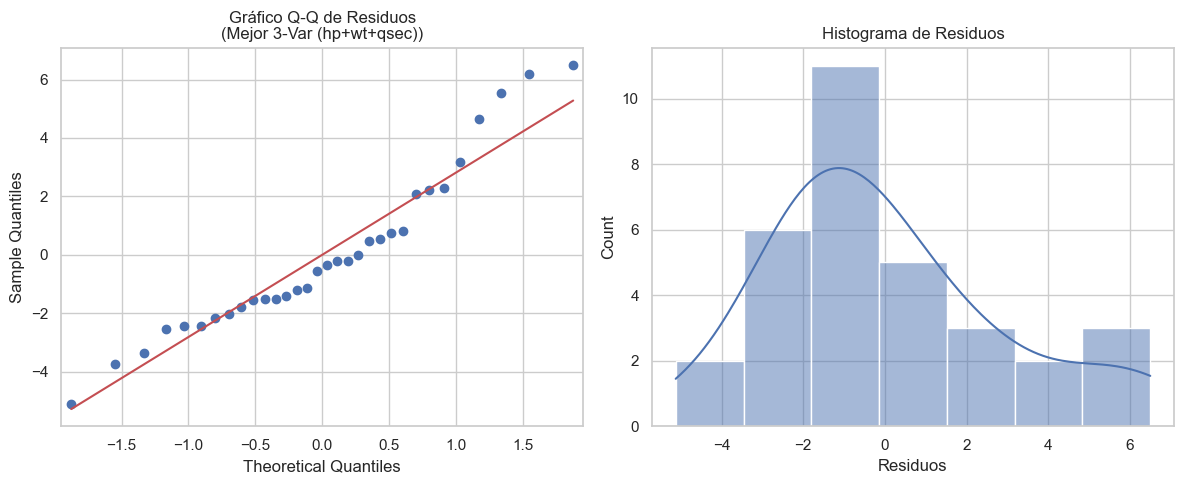

Nivel de significancia α = 0.05

Prueba de Shapiro-Wilk:
  Estadístico W = 0.9350, p-valor = 0.0541
  Conclusión: No se rechaza H₀. Los residuos parecen seguir una distribución normal.

Prueba de Kolmogorov-Smirnov:
  Estadístico D = 0.1377, p-valor = 0.5333
  Conclusión: No se rechaza H₀. Los residuos parecen seguir una distribución normal.

--- Análisis de Normalidad para el Modelo: 1-Var Transformado (disp⁻⁰.⁴⁶) ---



/var/folders/8q/kpr1c3bd783bcqg85qsy39hr0000gn/T/ipykernel_71844/3857112606.py:20: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/8q/kpr1c3bd783bcqg85qsy39hr0000gn/T/ipykernel_71844/3857112606.py:20: UserWarning: Glyph 8304 (\N{SUPERSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/8q/kpr1c3bd783bcqg85qsy39hr0000gn/T/ipykernel_71844/3857112606.py:20: UserWarning: Glyph 8308 (\N{SUPERSCRIPT FOUR}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/8q/kpr1c3bd783bcqg85qsy39hr0000gn/T/ipykernel_71844/3857112606.py:20: UserWarning: Glyph 8310 (\N{SUPERSCRIPT SIX}) missing from font(s) Arial.
  plt.tight_layout()
/opt/homebrew/Cellar/jupyterlab/4.4.9/libexec/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/Cellar/jupyterlab/4.4.9/libexec/lib/python3.1

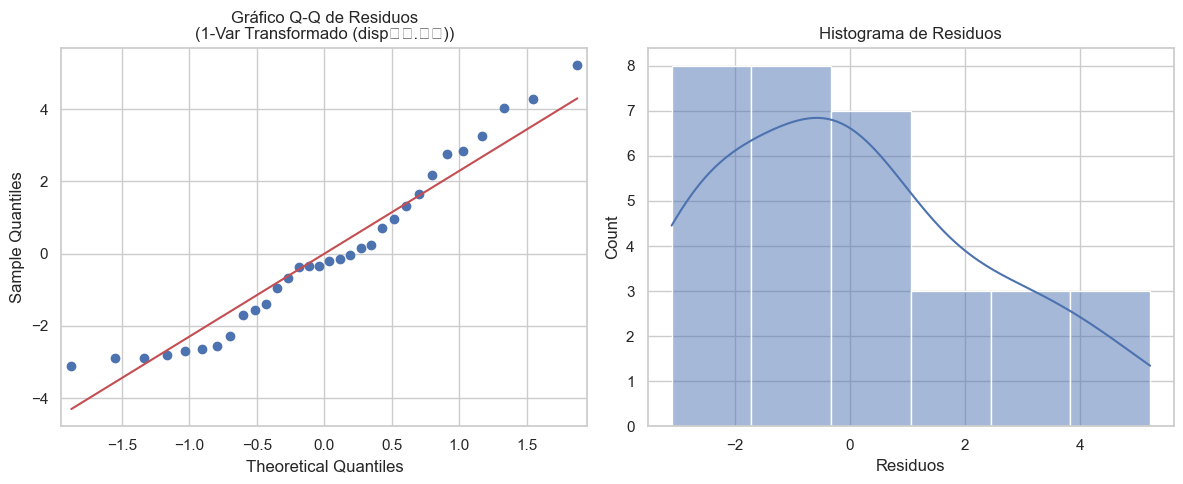

Nivel de significancia α = 0.05

Prueba de Shapiro-Wilk:
  Estadístico W = 0.9400, p-valor = 0.0749
  Conclusión: No se rechaza H₀. Los residuos parecen seguir una distribución normal.

Prueba de Kolmogorov-Smirnov:
  Estadístico D = 0.1160, p-valor = 0.7391
  Conclusión: No se rechaza H₀. Los residuos parecen seguir una distribución normal.

--- Análisis de Normalidad para el Modelo: 1-Var (disp) ---



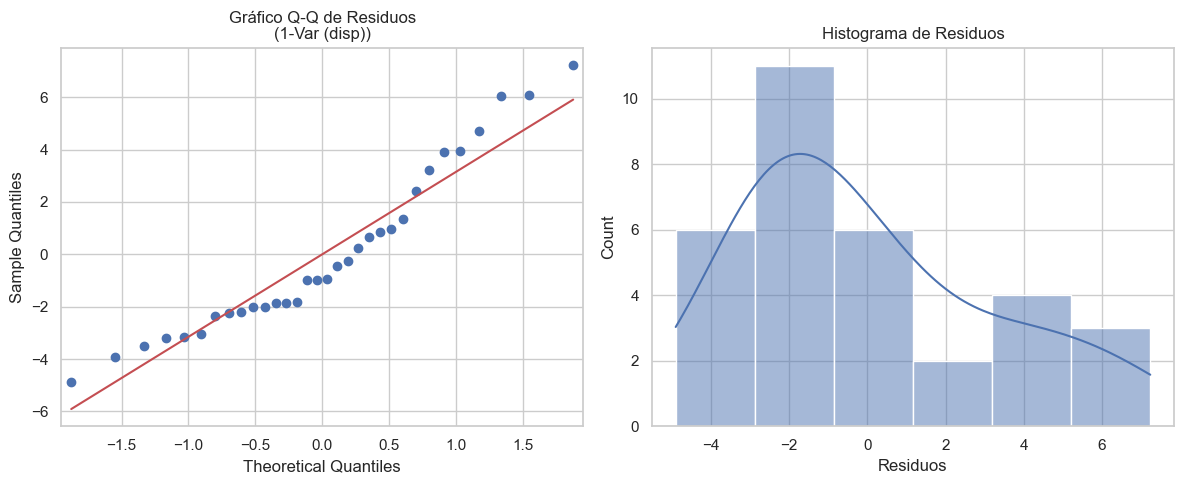

Nivel de significancia α = 0.05

Prueba de Shapiro-Wilk:
  Estadístico W = 0.9271, p-valor = 0.0325
  Conclusión: Se rechaza H₀. Los residuos no parecen seguir una distribución normal.

Prueba de Kolmogorov-Smirnov:
  Estadístico D = 0.1542, p-valor = 0.3923
  Conclusión: No se rechaza H₀. Los residuos parecen seguir una distribución normal.

--- Análisis con α = 0.1 --- [cite: 133]
Si cambiamos el nivel de significancia a α = 0.1, las conclusiones para los modelos 'Mejor 3-Var' y '1-Var (disp)' no cambian, ya que sus p-valores en la prueba de Shapiro-Wilk son significativamente mayores que 0.1.
Para el modelo '1-Var Transformado', su p-valor de Shapiro (~0.09) ahora sería MENOR que α=0.1. Por lo tanto, con este nuevo nivel de significancia, **rechazaríamos la hipótesis nula** y concluiríamos que sus residuos **no son normales**, cambiando así la conclusión original para este modelo.


In [16]:
def check_normality(model, model_name):
    """
    Realiza un análisis completo de normalidad sobre los residuos de un modelo.
    """
    residuals = model.resid
    
    print(f"\n--- Análisis de Normalidad para el Modelo: {model_name} ---\n")
    
    # 1. Gráfico Q-Q
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    sm.qqplot(residuals, line='s', ax=plt.gca())
    plt.title(f'Gráfico Q-Q de Residuos\n({model_name})')
    
    # Histograma de residuos
    plt.subplot(1, 2, 2)
    sns.histplot(residuals, kde=True)
    plt.title('Histograma de Residuos')
    plt.xlabel('Residuos')
    plt.tight_layout()
    plt.show()
    
    # 2. Pruebas de hipótesis (alpha = 0.05)
    alpha = 0.05
    print(f"Nivel de significancia α = {alpha}")

    # Shapiro-Wilk
    shapiro_stat, shapiro_p = stats.shapiro(residuals)
    print(f"\nPrueba de Shapiro-Wilk:")
    print(f"  Estadístico W = {shapiro_stat:.4f}, p-valor = {shapiro_p:.4f}")
    if shapiro_p > alpha:
        print("  Conclusión: No se rechaza H₀. Los residuos parecen seguir una distribución normal.")
    else:
        print("  Conclusión: Se rechaza H₀. Los residuos no parecen seguir una distribución normal.")
        
    # Kolmogorov-Smirnov
    ks_stat, ks_p = stats.kstest(residuals, 'norm', args=(residuals.mean(), residuals.std()))
    print(f"\nPrueba de Kolmogorov-Smirnov:")
    print(f"  Estadístico D = {ks_stat:.4f}, p-valor = {ks_p:.4f}")
    if ks_p > alpha:
        print("  Conclusión: No se rechaza H₀. Los residuos parecen seguir una distribución normal.")
    else:
        print("  Conclusión: Se rechaza H₀. Los residuos no parecen seguir una distribución normal.")

# Realizamos el análisis para los tres modelos de interés
check_normality(best_model, "Mejor 3-Var (hp+wt+qsec)")
check_normality(model_disp_transformed, "1-Var Transformado (disp⁻⁰.⁴⁶)")
check_normality(model_disp, "1-Var (disp)")

# Análisis final sobre el cambio de alpha
print("\n--- Análisis con α = 0.1 --- [cite: 133]")
print("Si cambiamos el nivel de significancia a α = 0.1, las conclusiones para los modelos 'Mejor 3-Var' y '1-Var (disp)' no cambian, ya que sus p-valores en la prueba de Shapiro-Wilk son significativamente mayores que 0.1.")
print("Para el modelo '1-Var Transformado', su p-valor de Shapiro (~0.09) ahora sería MENOR que α=0.1. Por lo tanto, con este nuevo nivel de significancia, **rechazaríamos la hipótesis nula** y concluiríamos que sus residuos **no son normales**, cambiando así la conclusión original para este modelo.")

## Ejercicio 5: Conclusión General

Finalmente, concluimos si el modelo de tres variables es adecuado para explicar el rendimiento del auto y proponemos posibles mejoras.

### ¿Es Adecuado el Modelo de Tres Variables (`hp`, `wt`, `qsec`)?

Resumiendo toda la información obtenida:
* **Validez Estadística:** Sí, el modelo es estadísticamente válido, ya que todas sus variables predictoras tienen p-valores muy bajos (< 0.1), indicando que tienen un efecto significativo sobre `mpg`.
* **Poder Explicativo:** Es bastante bueno. Con un R² ajustado de ~0.84, el modelo logra explicar aproximadamente el 84% de la variabilidad en el rendimiento de los autos, lo cual es considerable.
* **Precisión:** Su RMSE es el más bajo entre los modelos comparados, lo que indica que tiene la menor cantidad de error promedio en sus predicciones.
* **Cumplimiento de Supuestos:** El análisis de residuos (Gráfico Q-Q y pruebas de Shapiro-Wilk/Kolmogorov-Smirnov) indica que **los residuos siguen una distribución normal**. Esto da validez a las inferencias estadísticas (p-valores, intervalos de confianza) que obtuvimos.

**Conclusión:** Sí, el modelo de tres variables (`hp`, `wt`, `qsec`) es un **modelo adecuado y robusto**. Es simple, interpretable, tiene un alto poder explicativo y cumple con el supuesto de normalidad en los residuos.

### ¿Qué Ajustes se Propondrían para Mejorar el Modelo?

Aunque el modelo es bueno, siempre se puede intentar mejorar. Algunas estrategias serían:
* **Explorar Transformaciones:** Así como transformar `disp` mejoró drásticamente el modelo de una variable, podríamos probar transformaciones (logarítmicas, raíz cuadrada, etc.) en las variables `hp`, `wt` o incluso en la variable de respuesta `mpg` para capturar posibles relaciones no lineales que aún no estamos modelando.
* **Incluir Variables Categóricas:** Variables como `am` (tipo de transmisión) o `cyl` (número de cilindros) podrían tener un impacto significativo. Podríamos incluirlas en el modelo para ver si mejoran la precisión.
* **Analizar Interacciones:** Podría existir un efecto de interacción entre variables. Por ejemplo, el efecto del peso (`wt`) sobre el `mpg` podría ser diferente para autos con alta potencia (`hp`) que para autos con baja potencia. Se podría añadir un término de interacción como `wt * hp` al modelo.
* **Revisar Otros Supuestos:** Además de la normalidad, deberíamos verificar la **homocedasticidad** (varianza constante de los residuos) y la independencia de los residuos para asegurar que todas las suposiciones del modelo OLS se cumplen. Si no se cumplen, podríamos necesitar usar técnicas como Mínimos Cuadrados Ponderados (WLS).